# traQmania 06 — More qubits or better features?

The circuit encodes one observation scalar per qubit, so a wider circuit *is* a
wider sensor array: 4 → 6 → 8 → 10 qubits means 3 → 5 → 7 → 9 lidar rays plus
speed — or some of those rays traded for engineered, track-aware features. Does
either buy better driving?

An earlier version of this notebook answered from single runs and three-seed
spreads recorded in July 2026. The October 2026 audit changed how those have to
be read:

- with a nearest-neighbour CZ ring and 4 blocks, the 8- and 10-qubit circuits
  **hide part of the observation from every action**
  ([notebook 07](07_light_cones_and_classical_surrogates.ipynb) derives this);
- a policy that laps at one evaluation often does not lap at the next, so "the
  best lap of the best snapshot of one to three seeds" is an anecdote, not a
  measurement;
- those best snapshots were chosen on 4 distinct evaluation episodes.

So this notebook starts over, on the multi-seed studies in `data/studies/`
(made with `tools/study.py` in October 2026):

- **Part A** — what a wider circuit changes: observation, parameters, and
  what each action can see at the depth each profile ships with.
- **Part B** — oval and chicane at 4, 6, 8 (and 10) qubits against matched
  MLPs, with the 8-qubit depth experiment as the centrepiece.
- **Part C** — the hard track, gp, at 10 qubits: what a handful of runs can
  and cannot tell.
- **Part D** — engineered features: what they are, and what the July feature
  experiments did and did not show.

Nothing trains here. Every number is printed by a cell — from a study
summary, a packaged config profile, a bundled weights sidecar, or a
measurement the cell makes itself — and the prose only interprets those
outputs. Where a study was still running when this was written (10 qubits on
oval and chicane), the cells print a `PENDING` note and pick the data up on
re-execution as soon as its summary exists.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import copy
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from traqmania import records
from traqmania.agents.base import action_labels
from traqmania.agents.classical import MLPQFunction
from traqmania.agents.quantum import QuantumQFunction, lightcone
from traqmania.config import load_config
from traqmania.env.racing_env import FEATURE_KINDS, FEATURE_LABELS, CarObserver, RacingEnv
from traqmania.env.track import Track

# one colour and one marker per kind of driver, the same in every figure
C_FULL, C_BLIND, C_MLP = "#2a78d6", "#eb6834", "#1baf7a"
T_START = time.perf_counter()

study_dir = next((b / "data" / "studies" for b in [Path.cwd(), *Path.cwd().parents]
                  if (b / "data" / "studies").is_dir()), None)
if study_dir is None:
    print("data/studies not found (running outside the repo checkout): "
          "every study below is reported as PENDING")
else:
    names = sorted(p.name for p in study_dir.iterdir() if p.is_dir())
    print(f"data/studies: {len(names)} study summaries\n  " + ", ".join(names))

data/studies: 15 study summaries
  chicane_4q, chicane_q6, chicane_q8, combo_4q, gp_4q, gp_q10feat, gp_q10feat_july_recipe, oval_4q, oval_q6, oval_q8, pro, robust_chicane_4q, robust_oval_4q, robust_oval_q6, universal_4q


## How the evidence is organised

One (variant, seed) *cell* of a study is one complete training run. Afterwards
its best snapshot and its final parameters each drive **36 fresh greedy
episodes**. `tools/export_study.py` keeps a compact summary per study —
`report.json` (statistics over seeds) and `cells.json` (per-seed evaluation
logs) — and that is all this notebook reads. Per variant it reports:

- **reliability** — the fraction of those 36 episodes in which the *best
  snapshot* completes a lap, and the number of seeds whose best snapshot laps
  in at least half of them;
- **final parameters** — the same 36-episode check for the parameters training
  *ended* with. The gap between the two is what best-snapshot selection hides;
- **stability** — the mean lapped fraction over all in-training evaluations
  (12 distinct greedy episodes every 50 training episodes) after the first one
  that lapped. 1 means "once it laps, it keeps lapping";
- **first clean lap** — the training episode in which one of the exploring
  cars first completes a lap, and **episodes to ≥ 50 % / ≥ 90 %** — training
  episodes until a greedy in-training evaluation laps in that share of its
  episodes, for half of *all* seeds;
- **lap time** — the best snapshot's mean lap over its 36 episodes.

Over seeds, the tables show the interquartile mean (IQM) with a 95 %
percentile-bootstrap interval, both taken from the study report. To compare
two sets of seeds the notebook computes the **probability of improvement** —
the chance that a random seed of one beats a random seed of the other, ties
counting half — with the same bootstrap; an interval that excludes 0.5 is a
supported difference. (The method is the one `docs/SCIENCE.md` describes under
"Many seeds, proper statistics", following Agarwal et al. and Meyer et al. as
cited there.) With 6 to
10 seeds these intervals understate the uncertainty: read them as a lower
bound on it.

In [2]:
_LOADED = {}
PENDING = []  # (study, variant) asked for but without finished runs when this notebook ran


def load_study(name):
    '''Report and per-seed records of data/studies/<name>; None while that summary is missing.'''
    if name not in _LOADED:
        path = None if study_dir is None else study_dir / name
        if path is None or not (path / "report.json").is_file():
            _LOADED[name] = None
        else:
            cells = path / "cells.json"
            _LOADED[name] = {
                "report": json.loads((path / "report.json").read_text(encoding="utf-8")),
                "cells": json.loads(cells.read_text(encoding="utf-8")) if cells.is_file() else [],
            }
    return _LOADED[name]


def lane(study, variant):
    '''One variant of one study: its statistics over seeds plus its per-seed records.

    None while the study, or that variant, has no finished runs (remembered in PENDING);
    re-executing the notebook picks them up as soon as the summary exists.
    '''
    loaded = load_study(study)
    if loaded is None or variant not in loaded["report"]["variants"]:
        if (study, variant) not in PENDING:
            PENDING.append((study, variant))
        return None
    entry = dict(loaded["report"]["variants"][variant], study=study, variant=variant)
    entry["cells"] = sorted((c for c in loaded["cells"] if c["variant"] == variant),
                            key=lambda c: c["seed"])
    return entry


def pending_text(study, variant):
    return f"PENDING - data/studies/{study} has no finished '{variant}' runs yet"


def incomplete_text(entry):
    '''A note when a lane's study was exported before all of its seeds had finished.'''
    open_seeds = sorted([*entry["missing_seeds"], *entry["failed_seeds"]])
    if not open_seeds:
        return None
    return (f"INCOMPLETE - data/studies/{entry['study']} '{entry['variant']}': seeds {open_seeds} "
            f"not finished when it was exported; {entry['n_seeds']} seeds so far")


def shape(entry):
    '''(qubits, blocks) of a lane; blocks is None for the MLP.

    The depth is read off the parameter count, P = 3 L n + 8, so it does not depend on
    what the profile's default depth happens to be today.
    '''
    recipe = entry["recipe"]
    overrides = dict(item.split("=", 1) for item in recipe["overrides"])
    n = int(overrides.get("circuit.n_qubits",
                          load_config(recipe["profile"])["circuit"]["n_qubits"]))
    if recipe["agent"] != "quantum":
        return n, None
    return n, (entry["n_params"] - 8) // (3 * n)


def blind_pairs(n, layers):
    '''Number of (action, feature) pairs the light cone hides at this size and depth.'''
    return int((~lightcone.feature_visibility(n, layers)).sum())


def values(entry, key):
    '''Per-seed values of one metric; seeds without one (no lap -> no lap time) are left out.'''
    return [row[key] for row in entry["per_seed"] if row[key] is not None]


def ci_text(entry, key, fmt=".2f"):
    '''"IQM [95 % CI]" of a metric, as stored in the study report.'''
    stat = entry["metrics"][key]
    iqm = stat["iqm"]
    if iqm["value"] is None:
        return "-"
    text = f"{iqm['value']:{fmt}} "
    text += ("[one seed]" if iqm["ci_low"] is None
             else f"[{iqm['ci_low']:{fmt}}, {iqm['ci_high']:{fmt}}]")
    return text + (f" (n={stat['n']})" if stat["n"] != entry["n_seeds"] else "")


def prob_improvement(x, y):
    '''P(a random seed of x beats a random seed of y); ties count half.'''
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    diff = x[..., :, None] - y[..., None, :]
    wins = (diff > 0).sum(axis=(-2, -1)) + 0.5 * (diff == 0).sum(axis=(-2, -1))
    return wins / (x.shape[-1] * y.shape[-1])


def improvement(x, y, n_boot=2000, seed=0):
    '''(P, low, high): probability of improvement with a 95 % stratified percentile bootstrap
    over seeds - the estimator of tools/study.py, with its number of resamples and RNG seed.'''
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        return float("nan"), float("nan"), float("nan")
    point = float(prob_improvement(x, y))
    if min(x.size, y.size) < 2:  # one seed says nothing about the seed-to-seed spread
        return point, float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    bx = x[rng.integers(0, x.size, size=(n_boot, x.size))]
    by = y[rng.integers(0, y.size, size=(n_boot, y.size))]
    low, high = np.percentile(prob_improvement(bx, by), [2.5, 97.5])
    return point, float(low), float(high)


# metric, column label, True when a larger value is the better one
COMPARE = (("best_lapped_frac", "best snapshot laps", True),
           ("final_lapped_frac", "final params lap", True),
           ("stability", "more stable", True),
           ("first_clean_episode", "first lap earlier", False),
           ("best_mean_lap", "laps faster", False))


def compare(a, b):
    '''{metric: (P, low, high)} that lane `a` is better than lane `b`.'''
    out = {}
    for key, _, larger_is_better in COMPARE:
        x, y = np.asarray(values(a, key)), np.asarray(values(b, key))
        # a smaller-is-better metric is negated, so `a` is the first bootstrap stratum either
        # way (the convention of notebook 04 and docs/SCIENCE.md: the same intervals there)
        out[key] = improvement(x, y) if larger_is_better else improvement(-x, -y)
    return out


def verdict(p, low, high):
    '''"0.92 [0.72, 1.00] +": the sign appears when the interval excludes 0.5.'''
    if np.isnan(p):
        return "-"
    if np.isnan(low):
        return f"{p:.2f} [one seed]"
    return f"{p:.2f} [{low:.2f}, {high:.2f}] " + ("+" if low > 0.5 else "-" if high < 0.5 else " ")


# The bootstrap above must reproduce the numbers tools/study.py stored in the reports.
checked = 0
for name in ([] if study_dir is None else sorted(p.name for p in study_dir.iterdir())):
    loaded = load_study(name)
    if loaded is None:
        continue
    report = loaded["report"]
    for variant, entry in report["variants"].items():
        for key, stored in entry.get("vs_baseline", {}).items():
            baseline = report["variants"][report["baseline"]]
            mine = improvement(values(entry, key), values(baseline, key))
            theirs = (stored["p_improvement"], stored["ci_low"], stored["ci_high"])
            if None not in theirs:
                assert np.allclose(mine, theirs, atol=1e-9), (name, variant, key, mine, theirs)
                checked += 1
print(f"probability of improvement: {checked} comparisons stored in the study reports "
      "reproduced from their per-seed values")

probability of improvement: 104 comparisons stored in the study reports reproduced from their per-seed values


## A — What changes with the qubit count

The circuit puts one observation scalar on each qubit and reads the four
actions off qubits 0–3 at any size (notebook
[03](03_quantum_circuits_as_q_functions.ipynb)). A wider register therefore
changes exactly three things:

1. **the observation** — more inputs: more rays by default, or engineered
   features (Part D);
2. **the parameter count** — $P = 3Ln + 8$ for $L$ re-uploading blocks;
3. **what the readouts can reach.** With a nearest-neighbour CZ ring, the
   backward light cone of a readout widens by one qubit per block in each
   direction. After $L$ blocks $\langle Z_a\rangle$ depends only on the
   features within ring distance $L-1$ of qubit $a$, and every gate outside
   every cone is *dead*: its angle has exactly zero gradient for every input.
   Each action sees every feature only when $L \ge \lfloor n/2\rfloor + 1$.

[Notebook 07](07_light_cones_and_classical_surrogates.ipynb) derives the light
cone, checks it against the simulator and shows what it saves on hardware.
Here we only need the bookkeeping, computed from the packaged profile files
(`traqmania/config/q6.toml`, …) — so the table follows the profiles if their
depth changes. `<- ships` marks the depth a profile ships with; the other rows
are the alternatives the studies below compare.

In [3]:
PROFILES = (None, "q6", "q8", "q10")  # packaged config profiles; None is the 4-qubit default
ACTIONS = action_labels(4)
oval = Track.load("oval")


def observation_text(cfg):
    '''"3 rays + speed" for the [observation] of a config.'''
    obs = cfg["observation"]
    return " + ".join(f"{len(obs['ray_angles_deg'])} rays" if kind == "rays"
                      else FEATURE_LABELS.get(kind, kind) for kind in obs["features"])


def cone(n, layers):
    '''Light-cone bookkeeping of the n-qubit, `layers`-block circuit; nothing is simulated.'''
    mask = lightcone.live_parameter_mask(n, layers)
    live = int(mask["lam"].sum() + mask["theta"].sum())
    return {"circuit": 3 * layers * n, "live": live, "dead": 3 * layers * n - live,
            "blind": blind_pairs(n, layers)}


SHIPPED = {}  # qubits -> (blocks the profile ships with, feature names, config)
print(f"{'profile':<9}{'qubits':>6}  {'observation':<16}{'blocks':>7}{'params':>8}"
      f"{'circuit angles':>16}{'live':>6}{'dead':>6}{'blind pairs':>13}{'amplitudes':>12}"
      f"{'MLP params':>12}")
for profile in PROFILES:
    cfg = load_config(profile)
    n, layers = int(cfg["circuit"]["n_qubits"]), int(cfg["circuit"]["n_layers"])
    SHIPPED[n] = (layers, CarObserver(oval, cfg).feature_names, cfg)
    full = lightcone.min_layers_full_visibility(n)
    mlp = MLPQFunction(n_features=n, hidden=int(cfg.get("mlp", {}).get("hidden", 8))).n_params
    for depth in sorted({4, layers, max(full, layers)}):
        c = cone(n, depth)
        blind = f"{c['blind']} of {4 * n}"
        print(f"{profile or 'default':<9}{n:>6}  {observation_text(cfg):<16}{depth:>7}"
              f"{c['circuit'] + 8:>8}{c['circuit']:>16}{c['live']:>6}{c['dead']:>6}{blind:>13}"
              f"{2 ** n:>12}{mlp:>12}" + ("   <- ships" if depth == layers else ""))

print("\nWhat each action can see at the depth its profile ships with:")
for n, (layers, names, _) in SHIPPED.items():
    hidden = lightcone.blind_spots(names, layers)
    need = lightcone.min_layers_full_visibility(n)
    print(f"  {n} qubits, {layers} blocks (full view needs {need}): "
          + ("every action sees every feature" if not hidden
             else f"{blind_pairs(n, layers)} action-feature pairs hidden"))
    for line in hidden:
        print(f"      {line}")

profile  qubits  observation      blocks  params  circuit angles  live  dead  blind pairs  amplitudes  MLP params
default       4  3 rays + speed        4      56              48    44     4      0 of 16          16          76   <- ships
q6            6  5 rays + speed        4      80              72    60    12      0 of 24          64          92   <- ships
q8            8  7 rays + speed        4     104              96    70    26      4 of 32         256         108
q8            8  7 rays + speed        5     128             120    94    26      0 of 32         256         108   <- ships
q10          10  9 rays + speed        4     128             120    74    46     12 of 40        1024         124   <- ships
q10          10  9 rays + speed        6     188             180   134    46      0 of 40        1024         124

What each action can see at the depth its profile ships with:
  4 qubits, 4 blocks (full view needs 3): every action sees every feature
  6 qubits, 4 blocks 

Three things to carry from this table into the experiments:

- **The parameter count overstates the model.** $P$ counts dead angles too,
  and their share grows with the register, because the readout stays on four
  qubits while the ring gets longer (columns *live* and *dead*). "Matched in
  parameter count" is therefore a loose notion on the circuit's side — the
  MLP's column is the hidden-8 network on the same observation, every weight
  of which is live.
- **Depth and width are coupled.** At 4 blocks the 4- and 6-qubit circuits
  show every feature to every action; 8 qubits hide one feature from each
  action and 10 qubits hide three (*blind pairs*). A "more qubits" comparison
  at a fixed depth of 4 therefore changes two things at once: more inputs, and
  a smaller share of them visible to each action. Every July comparison was of
  that kind. The lines under the table say where each profile stands now.
- **The simulation bill doubles with every qubit** (*amplitudes*), while the
  MLP grows by eight weights per extra input.

## B — Do more qubits drive better? Oval and chicane, many seeds

**The lanes.** One training recipe at every size — the default oval/chicane
schedule plus `bootstrap_truncation`, 800 episodes — for the circuit and for
an MLP that gets the *same observation* (one hidden layer of 8 tanh units).
At 8 and 10 qubits the circuit was trained at two depths: 4 blocks, which is
how those sizes shipped until October 2026, and the smallest depth with full
visibility. The cell prints seeds and recipe of every lane as recorded in its
study report.

Rows marked *robust* are a different recipe: today's default for the circuit
on oval and chicane, and the one the bundled 4-qubit oval/chicane and 6-qubit
oval drivers were trained with (a wider action gap and noisy acting, for the
hardware demo of [notebook 05](05_real_quantum_hardware.ipynb);
[notebook 04](04_training_the_quantum_driver.ipynb) compares circuit and MLP
at 4 qubits under it). It was run at 4 and 6 qubits only, so it is listed for
reference and left out of the comparisons across sizes.

In [4]:
TRACKS = ("oval", "chicane")
SIZES = (4, 6, 8, 10)
LANES = {  # (track, qubits) -> [(study, variant, kind)]; kind: circuit | mlp | robust
    ("oval", 4): [("oval_4q", "trunc", "circuit"), ("oval_4q", "mlp_trunc", "mlp"),
                  ("robust_oval_4q", "gap8an", "robust")],
    ("oval", 6): [("oval_q6", "quantum", "circuit"), ("oval_q6", "mlp", "mlp"),
                  ("robust_oval_q6", "gap8an", "robust")],
    ("oval", 8): [("oval_q8", "L4", "circuit"), ("oval_q8", "L5", "circuit"),
                  ("oval_q8", "mlp", "mlp")],
    ("oval", 10): [("oval_q10", "L4", "circuit"), ("oval_q10", "L6", "circuit"),
                   ("oval_q10", "mlp", "mlp")],
    ("chicane", 4): [("chicane_4q", "trunc", "circuit"), ("chicane_4q", "mlp_trunc", "mlp"),
                     ("robust_chicane_4q", "gap8an", "robust")],
    ("chicane", 6): [("chicane_q6", "quantum", "circuit"), ("chicane_q6", "mlp", "mlp")],
    ("chicane", 8): [("chicane_q8", "L4", "circuit"), ("chicane_q8", "L5", "circuit"),
                     ("chicane_q8", "mlp", "mlp")],
    ("chicane", 10): [("chicane_q10", "L4", "circuit"), ("chicane_q10", "L6", "circuit"),
                      ("chicane_q10", "mlp", "mlp")],
}
KIND_LABEL = {"circuit": "circuit", "mlp": "MLP", "robust": "circuit, robust"}


def scaling_rows(track):
    '''(rows that exist, pending notes) of one track, in table order.'''
    rows, notes = [], []
    for n in SIZES:
        for study, variant, kind in LANES[(track, n)]:
            entry = lane(study, variant)
            if entry is None:
                notes.append(f"{n:>6}  {KIND_LABEL[kind]:<15} {pending_text(study, variant)}")
                continue
            qubits, layers = shape(entry)
            assert qubits == n, (study, variant, qubits)
            if incomplete_text(entry):
                notes.append(f"{n:>6}  {KIND_LABEL[kind]:<15} {incomplete_text(entry)}")
            rows.append({"qubits": n, "kind": kind, "layers": layers, "entry": entry,
                         "blind": None if layers is None else blind_pairs(n, layers)})
    return rows, notes


def series_of(row):
    '''full | blind | mlp: which of the three kinds of driver a row is.'''
    return "mlp" if row["kind"] == "mlp" else "blind" if row["blind"] else "full"


def recipe_text(entry):
    recipe = entry["recipe"]
    extra = [o for o in recipe["overrides"] if not o.startswith("circuit.n_layers")]
    return f"{recipe['episodes']} episodes; " + ", ".join(extra)


for track in TRACKS:
    rows, notes = scaling_rows(track)
    print(f"=== {track}: reliability and stability (IQM over seeds [95 % CI]) ===")
    print(f"{'qubits':>6}  {'driver':<15}{'blocks':>6}{'params':>7}{'blind':>6}{'seeds':>6}"
          f"{'reliable':>9}   {'best snapshot lapped':<22}{'final params lapped':<22}"
          f"{'stability':<20}")
    for r in rows:
        e = r["entry"]
        reliable = f"{e['reliable_seeds']}/{e['n_seeds']}"
        blind = "-" if r["blind"] is None else r["blind"]
        print(f"{r['qubits']:>6}  {KIND_LABEL[r['kind']]:<15}{r['layers'] or '-':>6}"
              f"{e['n_params']:>7}{blind:>6}{e['n_seeds']:>6}{reliable:>9}   "
              f"{ci_text(e, 'best_lapped_frac'):<22}{ci_text(e, 'final_lapped_frac'):<22}"
              f"{ci_text(e, 'stability'):<20}")
    print(f"\n=== {track}: speed of learning and of driving ===")
    print(f"{'qubits':>6}  {'driver':<15}{'blocks':>6}   {'first clean lap (episode)':<27}"
          f"{'episodes to >=50% / >=90%':<27}{'mean lap of best snapshot (s)':<30}")
    for r in rows:
        e = r["entry"]
        half = [e["sample_complexity"][k]["episodes_half_of_seeds"]
                for k in ("episodes_to_50", "episodes_to_90")]
        reach = " / ".join("-" if v is None else str(v) for v in half)
        print(f"{r['qubits']:>6}  {KIND_LABEL[r['kind']]:<15}{r['layers'] or '-':>6}   "
              f"{ci_text(e, 'first_clean_episode', '.0f'):<27}{reach:<27}"
              f"{ci_text(e, 'best_mean_lap', '.1f'):<30}")
    for note in notes:
        print(note)
    recipes = {}
    for r in rows:
        recipes.setdefault(recipe_text(r["entry"]), set()).add(KIND_LABEL[r["kind"]])
    for text, kinds in recipes.items():
        print(f"recipe of the rows '{', '.join(sorted(kinds))}': {text}")
    print()

=== oval: reliability and stability (IQM over seeds [95 % CI]) ===
qubits  driver         blocks params blind seeds reliable   best snapshot lapped  final params lapped   stability           
     4  circuit             4     56     0     8      8/8   1.00 [0.98, 1.00]     0.84 [0.57, 0.97]     0.69 [0.57, 0.75]   
     4  MLP                 -     76     -     8      8/8   1.00 [1.00, 1.00]     1.00 [0.98, 1.00]     0.94 [0.87, 0.99]   
     4  circuit, robust     4     56     0    10    10/10   1.00 [0.94, 1.00]     0.80 [0.47, 0.99]     0.75 [0.52, 0.92]   
     6  circuit             4     80     0     8      8/8   1.00 [0.99, 1.00]     1.00 [0.81, 1.00]     0.75 [0.58, 0.85]   
     6  MLP                 -     92     -     8      8/8   1.00 [1.00, 1.00]     1.00 [1.00, 1.00]     0.87 [0.81, 0.93]   
     6  circuit, robust     4     80     0     8      8/8   1.00 [0.99, 1.00]     0.89 [0.55, 1.00]     0.86 [0.79, 0.93]   
     8  circuit             4    104     4     6      5/6 

*Reliable* counts the seeds whose best snapshot laps in at least half of its
36 check episodes; *blind* is the number of action–feature pairs the light
cone hides at that depth; "episodes to" is `-` when fewer than half of the
seeds ever get there. The same lanes as a picture — markers are the IQM, bars
the 95 % interval, small dots the single seeds:

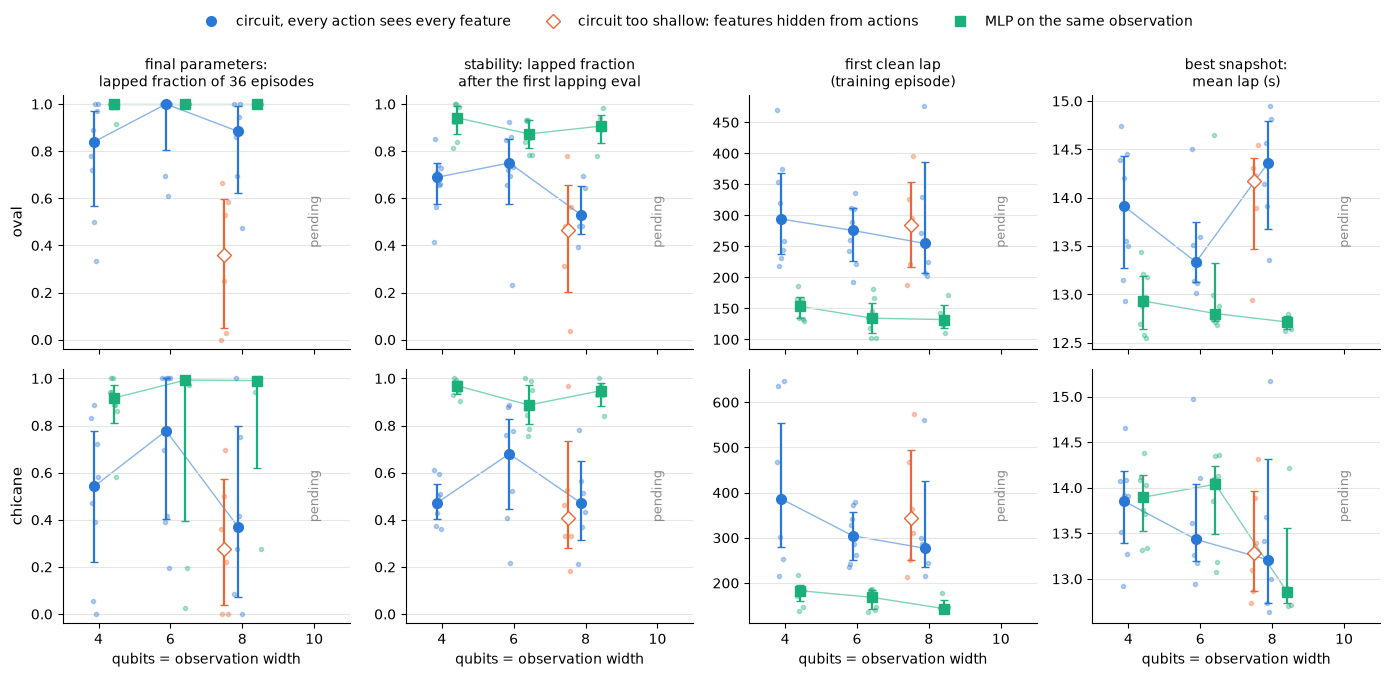

In [5]:
PANELS = (("final_lapped_frac", "final parameters:\nlapped fraction of 36 episodes"),
          ("stability", "stability: lapped fraction\nafter the first lapping eval"),
          ("first_clean_episode", "first clean lap\n(training episode)"),
          ("best_mean_lap", "best snapshot:\nmean lap (s)"))
STYLE = {"full": (C_FULL, "o", "circuit, every action sees every feature"),
         "blind": (C_BLIND, "D", "circuit too shallow: features hidden from actions"),
         "mlp": (C_MLP, "s", "MLP on the same observation")}
OFFSET = {"blind": -0.5, "full": -0.12, "mlp": 0.42}

fig, axes = plt.subplots(len(TRACKS), len(PANELS), figsize=(14, 6.6), sharex=True)
for row_axes, track in zip(axes, TRACKS, strict=True):
    rows = [r for r in scaling_rows(track)[0] if r["kind"] != "robust"]
    for ax, (key, title) in zip(row_axes, PANELS, strict=True):
        trend = {"full": [], "mlp": []}
        for r in rows:
            series = series_of(r)
            color, marker, _ = STYLE[series]
            x = r["qubits"] + OFFSET[series]
            seeds = values(r["entry"], key)
            ax.plot(x + np.linspace(-0.1, 0.1, len(seeds)), seeds, ".", color=color,
                    alpha=0.35, ms=6, zorder=2)
            iqm = r["entry"]["metrics"][key]["iqm"]
            if iqm["value"] is None:
                continue
            err = None if iqm["ci_low"] is None else [[iqm["value"] - iqm["ci_low"]],
                                                      [iqm["ci_high"] - iqm["value"]]]
            ax.errorbar(x, iqm["value"], yerr=err, fmt=marker, color=color, ms=7, capsize=3,
                        mfc="white" if series == "blind" else color, lw=1.6, zorder=3)
            if series in trend:
                trend[series].append((x, iqm["value"]))
        for series, points in trend.items():
            if len(points) > 1:
                ax.plot(*zip(*points, strict=True), "-", color=STYLE[series][0], lw=1,
                        alpha=0.55, zorder=1)
        for n in SIZES:
            if not any(r["qubits"] == n for r in rows):
                ax.text(n, 0.5, "pending", rotation=90, color="0.55", ha="center", va="center",
                        transform=ax.get_xaxis_transform(), fontsize=9)
        if key in ("final_lapped_frac", "stability"):
            ax.set_ylim(-0.04, 1.04)
        ax.set_xticks(SIZES)
        ax.set_xlim(SIZES[0] - 1, SIZES[-1] + 1)
        ax.grid(axis="y", color="0.9", lw=0.8)
        ax.spines[["top", "right"]].set_visible(False)
        if track == TRACKS[0]:
            ax.set_title(title, fontsize=10)
        if track == TRACKS[-1]:
            ax.set_xlabel("qubits = observation width")
    row_axes[0].set_ylabel(track, fontsize=11)
handles = [plt.Line2D([], [], color=c, marker=m, ls="", ms=7, label=label,
                      mfc="white" if name == "blind" else c)
           for name, (c, m, label) in STYLE.items()]
fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, 1.03))
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

**What the lanes say** (numbers: the tables above).

- *The circuit learns to lap at every size.* For most seeds the best snapshot
  laps in all, or nearly all, of its 36 check episodes, and the first clean
  lap arrives after a few hundred episodes whatever the width. The exceptions
  are whole seeds that never get a snapshot lapping in half of its check
  episodes: one of eight at 4 qubits on the chicane, and one of six in each
  of the too-shallow 8-qubit lanes (column *reliable*).
- *Wider is not better, and it is not even monotone.* Of the three completed
  sizes, six qubits have the best point estimates for final parameters and
  for stability on both tracks. Eight qubits fall back to the 4-qubit level
  or below it on both, at either depth. Lap time shows no consistent order:
  six qubits are fastest on the oval, eight on the chicane, with overlapping
  intervals.
- *The MLP is ahead on almost every metric.* It drives its first clean lap
  after roughly half as many episodes, keeps lapping once it laps (stability
  0.87–0.97 against 0.41–0.75 for the circuit under the same recipe) and its
  final parameters still lap in most seeds (IQM 0.92–1.00). On the oval it is
  also faster at every size. The circuit holds its own in two places: pace on
  the chicane, where the best snapshots of the 4- and 6-qubit circuits are as
  fast as the MLP's or faster, with overlapping intervals; and stability at 6
  qubits on the oval under the *robust* recipe, 0.86 against the MLP's 0.87
  (the two robust lanes at 4 qubits stay well below their MLPs: 0.75 and
  0.63).
- *Getting there is not the circuit's problem; staying there is.* Compare the
  two "lapped" columns: best snapshots near 1, final parameters far below.
  That gap is what a table of best snapshots — every table this notebook used
  to show — cannot see.

Which of these differences are statistically supported is computed further
down. First, the one experiment in these lanes that changes a single thing.

### The centrepiece: 8 qubits, 4 blocks against 5

Same 8-qubit observation (7 rays + speed), same recipe, same six seeds, same
evaluation. The only difference between the two arms is the number of
re-uploading blocks: 4, at which each action is blind to one input, or 5, at
which every action sees everything. If hiding inputs from actions matters,
this is where it shows.

It is not perfectly clean. The fifth block also brings 24 more parameters and
a fifth upload of every feature, so "depth" and "visibility" move together; a
control for depth alone follows below.

In [6]:
def depth_lanes(n):
    '''{track: {"shallow", "deep", "mlp"}} of the depth experiment at n qubits, plus notes
    for whatever is not there yet. Shallow is 4 blocks, deep the smallest fully sighted depth.'''
    full = lightcone.min_layers_full_visibility(n)
    found, notes = {}, []
    for track in TRACKS:
        study = f"{track}_q{n}"
        arms = {"shallow": lane(study, "L4"), "deep": lane(study, f"L{full}"),
                "mlp": lane(study, "mlp")}
        for arm, variant in (("shallow", "L4"), ("deep", f"L{full}"), ("mlp", "mlp")):
            if arms[arm] is None:
                notes.append(f"{n} qubits, {track}: {pending_text(study, variant)}")
            elif incomplete_text(arms[arm]):
                notes.append(f"{n} qubits, {track}: {incomplete_text(arms[arm])}")
        if arms["shallow"] is not None and arms["deep"] is not None:
            found[track] = arms
    return full, found, notes


def depth_table(n):
    '''What the two depths can see, and every seed of every arm.'''
    full, found, notes = depth_lanes(n)
    _, feature_names, _ = SHIPPED[n]
    for depth in (4, full):
        c = cone(n, depth)
        print(f"{n} qubits, {depth} blocks: {c['circuit'] + 8} parameters, {c['dead']} of the "
              f"{c['circuit']} circuit angles dead, {c['blind']} action-feature pairs hidden")
        for line in lightcone.blind_spots(feature_names, depth):
            print(f"      {line}")
    for note in notes:
        print(note)
    for track, arms in found.items():
        seeds = sorted({row["seed"] for arm in arms.values() if arm for row in arm["per_seed"]})
        head = f"{track}, {n} qubits"
        print(f"\n{head:<42}seed" + "".join(f"{s:>7}" for s in seeds) + "    IQM [95 % CI]")
        for arm, entry in arms.items():
            if entry is None:
                continue
            _, layers = shape(entry)
            label = "MLP" if arm == "mlp" else f"{layers} blocks"
            label += f" ({entry['n_params']} params)"
            by_seed = {row["seed"]: row for row in entry["per_seed"]}
            for title, key, per_seed in (
                    ("best snapshot laps", "best_lapped_frac",
                     lambda row: f"{row['best_lapped']}/{row['eval_episodes']}"),
                    ("final params lap", "final_lapped_frac",
                     lambda row: f"{row['final_lapped']}/{row['eval_episodes']}"),
                    ("stability", "stability",
                     lambda row: "-" if row["stability"] is None else f"{row['stability']:.2f}"),
                    ("mean lap (s)", "best_mean_lap",
                     lambda row: "-" if row["best_mean_lap"] is None
                     else f"{row['best_mean_lap']:.1f}")):
                cells = "".join(f"{per_seed(by_seed[s]) if s in by_seed else '':>7}"
                                for s in seeds)
                fmt = ".1f" if key == "best_mean_lap" else ".2f"
                print(f"  {label:<22}{title:<22}{cells}    {ci_text(entry, key, fmt)}")
                label = ""


depth_table(8)

8 qubits, 4 blocks: 104 parameters, 26 of the 96 circuit angles dead, 4 action-feature pairs hidden
      Right (Z_0) cannot see: ray +20°
      Straight (Z_1) cannot see: ray +40°
      Left (Z_2) cannot see: ray +60°
      Brake (Z_3) cannot see: speed
8 qubits, 5 blocks: 128 parameters, 26 of the 120 circuit angles dead, 0 action-feature pairs hidden

oval, 8 qubits                            seed      0      1      2      3      4      5    IQM [95 % CI]
  4 blocks (104 params) best snapshot laps      36/36  35/36  36/36  36/36   8/36  36/36    1.00 [0.60, 1.00]
                        final params lap         0/36  24/36   9/36  19/36   1/36  21/36    0.36 [0.05, 0.60]
                        stability                0.31   0.48   0.78   0.47   0.04   0.56    0.46 [0.20, 0.66]
                        mean lap (s)             14.2   12.9   14.3   14.2   13.9   14.6    14.2 [13.5, 14.4]
  5 blocks (128 params) best snapshot laps      33/36  36/36  36/36  36/36  36/36  31/36    0.99 

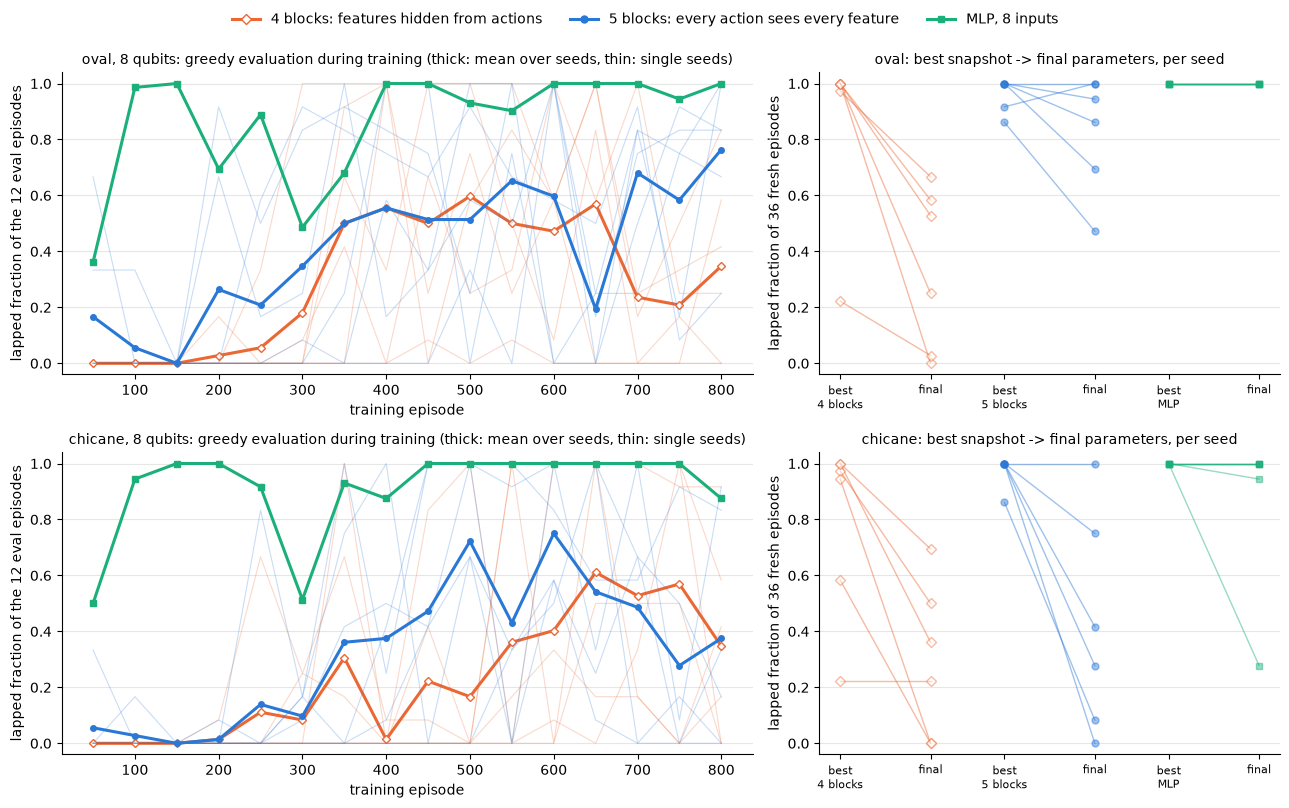

In [7]:
ARM_STYLE = {"shallow": (C_BLIND, "D"), "deep": (C_FULL, "o"), "mlp": (C_MLP, "s")}


def eval_curves(entry, every=50):
    '''(episodes, lapped fraction per seed) from the in-training evaluations of a lane.

    An evaluation runs when the episode count passes a multiple of `every`; with 8 cars in
    parallel that can be an episode or two late, so each one is filed under its multiple.
    '''
    def nominal(e):
        return every * round(e["episode"] / every)

    episodes = sorted({nominal(e) for c in entry["cells"] for e in c["eval_log"]})
    curves = np.full((len(entry["cells"]), len(episodes)), np.nan)
    for i, c in enumerate(entry["cells"]):
        for e in c["eval_log"]:
            if e["eval_episodes"]:
                curves[i, episodes.index(nominal(e))] = e["lapped_episodes"] / e["eval_episodes"]
    return np.array(episodes), curves


def depth_figure(n):
    '''In-training evaluations and the best-snapshot -> final-parameters drop, per arm.'''
    _, found, _ = depth_lanes(n)
    if not found:
        print(f"{n} qubits: no depth experiment to draw yet")
        return
    fig, axes = plt.subplots(len(found), 2, figsize=(13, 0.5 + 3.8 * len(found)), squeeze=False,
                             gridspec_kw={"width_ratios": (1.5, 1)})
    legend = {}
    for (track, arms), (ax, ax2) in zip(found.items(), axes, strict=True):
        labels, ticks = {}, []
        for k, (arm, entry) in enumerate((a, e) for a, e in arms.items() if e is not None):
            color, marker = ARM_STYLE[arm]
            n_in, layers = shape(entry)
            labels[arm] = "MLP" if arm == "mlp" else f"{layers} blocks"
            note = (f"MLP, {n_in} inputs" if arm == "mlp" else f"{layers} blocks: "
                    + ("features hidden from actions" if blind_pairs(n_in, layers)
                       else "every action sees every feature"))
            legend[arm] = plt.Line2D([], [], color=color, marker=marker, lw=2.2, ms=5, label=note,
                                     mfc="white" if arm == "shallow" else color)
            if not entry["cells"]:
                continue
            episodes, curves = eval_curves(entry)
            if arm != "mlp":
                ax.plot(episodes, curves.T, color=color, lw=0.8, alpha=0.25)
            ax.plot(episodes, np.nanmean(curves, axis=0), color=color, lw=2.2, marker=marker,
                    ms=4, mfc="white" if arm == "shallow" else color)
            # right: every seed's best snapshot and final parameters over 36 fresh episodes
            x = np.array([k, k + 0.55])
            for row in entry["per_seed"]:
                ax2.plot(x, [row["best_lapped_frac"], row["final_lapped_frac"]], "-",
                         color=color, lw=1, alpha=0.45, marker=marker, ms=5,
                         mfc="white" if arm == "shallow" else color)
            ticks += [(x[0], f"best\n{labels[arm]}"), (x[1], "final")]
        ax.set(xlabel="training episode", ylim=(-0.04, 1.04),
               ylabel="lapped fraction of the 12 eval episodes")
        ax.set_title(f"{track}, {n} qubits: greedy evaluation during training "
                     "(thick: mean over seeds, thin: single seeds)", fontsize=10)
        ax2.set_xticks([t for t, _ in ticks], [label for _, label in ticks], fontsize=8)
        ax2.set(ylim=(-0.04, 1.04), ylabel="lapped fraction of 36 fresh episodes")
        ax2.set_title(f"{track}: best snapshot -> final parameters, per seed", fontsize=10)
        for a in (ax, ax2):
            a.grid(axis="y", color="0.9", lw=0.8)
            a.spines[["top", "right"]].set_visible(False)
    fig.legend(handles=list(legend.values()), loc="upper center", ncol=3, frameon=False,
               fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.35 / fig.get_figheight()))
    plt.show()


depth_figure(8)

In [8]:
def depth_stats(n):
    '''Probability that a seed of the deep arm beats a seed of the shallow arm, per metric.'''
    full, found, _ = depth_lanes(n)
    if not found:
        print(f"{n} qubits: no depth experiment to compare yet")
        return
    print(f"{n} qubits: P({full} blocks better than 4 blocks) [95 % CI];  "
          "+ / - marks an interval that excludes 0.5\n")
    print(f"{'':<10}{'reliable seeds':<18}" + "".join(f"{label:<24}" for _, label, _ in COMPARE))
    n_intervals = n_excluding = 0
    for track, arms in found.items():
        shallow, deep = arms["shallow"], arms["deep"]
        reliable = (f"{deep['reliable_seeds']}/{deep['n_seeds']} vs "
                    f"{shallow['reliable_seeds']}/{shallow['n_seeds']}")
        result = compare(deep, shallow)
        for _, low, high in result.values():
            if not np.isnan(low):
                n_intervals += 1
                n_excluding += int(low > 0.5 or high < 0.5)
        print(f"{track:<10}{reliable:<18}"
              + "".join(f"{verdict(*result[key]):<24}" for key, _, _ in COMPARE))
    if n_intervals:
        print(f"\n{n_excluding} of {n_intervals} intervals exclude 0.5. With no real difference "
              f"between the depths, the chance that at least one of {n_intervals}\nindependent "
              f"95 % intervals did so would be {1 - 0.95 ** n_intervals:.2f}.")


depth_stats(8)

8 qubits: P(5 blocks better than 4 blocks) [95 % CI];  + / - marks an interval that excludes 0.5

          reliable seeds    best snapshot laps      final params lap        more stable             first lap earlier       laps faster             
oval      6/6 vs 5/6        0.50 [0.22, 0.78]       0.92 [0.72, 1.00] +     0.67 [0.33, 0.97]       0.53 [0.19, 0.89]       0.36 [0.08, 0.75]       
chicane   6/6 vs 5/6        0.75 [0.46, 1.00]       0.61 [0.25, 0.92]       0.58 [0.22, 0.92]       0.64 [0.28, 1.00]       0.53 [0.17, 0.86]       

1 of 10 intervals exclude 0.5. With no real difference between the depths, the chance that at least one of 10
independent 95 % intervals did so would be 0.40.


**Reading the experiment.**

- **Oval.** The final parameters of the 5-block circuit lap in 17 to 36 of
  their 36 check episodes, depending on the seed; those of the 4-block
  circuit in 0 to 24. That is the one difference in this experiment whose
  interval excludes 0.5 — one of ten intervals, and the last line of the
  output says how often ten such intervals would produce a mark by chance.
  For the best snapshot, stability, first lap and pace the two depths cannot
  be told apart.
- **Chicane.** Every point estimate favours 5 blocks, and no interval
  excludes 0.5.
- **Seeds that never get there.** At 4 blocks one seed in six, on each track,
  never produced a snapshot that laps in half of its check episodes; at 5
  blocks all six do on both tracks (*reliable seeds*).
- **Pace** cannot be told apart between the depths, and **stability** stays
  far below the MLP's at either depth: the right-hand panels show the same
  drop from best snapshot to final parameters in both circuit arms, only less
  deep at 5 blocks on the oval.

So the evidence that giving every action the whole observation makes the
8-qubit circuit more dependable is thin: one supported difference on one
track, the same direction without support in most of the rest, and nothing
on the dependability side that points the other way. It does not make the
circuit faster, and it does not bring its stability level with the 6-qubit
circuit's, let alone the MLP's. Six seeds per arm is a small experiment. The
`q8` profile was moved to 5 blocks all the same, because nothing in the data
speaks for the blind circuit and the structural argument needs no seeds: at
4 blocks Brake cannot see the speed.

**Is it the visibility, or just the extra block?** The experiment cannot
separate the two, but a different study offers a control. At 4 qubits every
action already sees every feature from 3 blocks on, so more blocks add
parameters and re-uploads and *no* visibility. The stabilisation study on gp
trained such circuits with 6 and 8 blocks (pre-audit recipe, the same for all
three arms):

In [9]:
arms = {name: lane("gp_4q", name) for name in ("base", "L6", "L8")}
if any(entry is None for entry in arms.values()):
    for name, entry in arms.items():
        if entry is None:
            print(pending_text("gp_4q", name))
else:
    print("gp, 4 qubits, pre-audit recipe: more blocks without more visibility\n")
    print(f"{'blocks':>6}{'params':>8}{'blind':>7}{'seeds':>7}{'reliable':>10}   "
          f"{'best snapshot lapped':<22}{'stability':<20}{'mean lap (s)':<26}"
          f"{'P(best snapshot laps more than at 4 blocks)'}")
    for name, entry in arms.items():
        n, layers = shape(entry)
        p = "" if name == "base" else verdict(*improvement(
            values(entry, "best_lapped_frac"), values(arms["base"], "best_lapped_frac")))
        reliable = f"{entry['reliable_seeds']}/{entry['n_seeds']}"
        print(f"{layers:>6}{entry['n_params']:>8}{blind_pairs(n, layers):>7}{entry['n_seeds']:>7}"
              f"{reliable:>10}   {ci_text(entry, 'best_lapped_frac'):<22}"
              f"{ci_text(entry, 'stability'):<20}{ci_text(entry, 'best_mean_lap', '.1f'):<26}{p}")

gp, 4 qubits, pre-audit recipe: more blocks without more visibility

blocks  params  blind  seeds  reliable   best snapshot lapped  stability           mean lap (s)              P(best snapshot laps more than at 4 blocks)
     4      56      0     10      9/10   0.89 [0.74, 0.97]     0.08 [0.04, 0.15]   34.7 [29.0, 43.1]         
     6      80      0      6       3/6   0.55 [0.18, 0.92]     0.04 [0.01, 0.14]   27.4 [23.9, 29.8] (n=5)   0.31 [0.00, 0.64]  
     8     104      0      6       5/6   0.60 [0.38, 0.80]     0.08 [0.05, 0.15]   26.3 [22.1, 28.1]         0.20 [0.00, 0.50]  


More blocks without more visibility did not make the 4-qubit circuit more
reliable on gp — the point estimates go the other way (fewer reliable seeds,
lower lapped fractions), with somewhat faster laps for the seeds that do lap.
That is a different track and the pre-audit recipe, so it is indirect
evidence; but it gives no support to "any extra block would have helped at 8
qubits". Where the fifth block did help at 8 qubits — the final parameters
on the oval — the simplest reading remains that it did so because of what it
lets the actions see: a reading, not a proof.

### Wider against narrower, circuit against MLP: which differences are supported?

The same probability of improvement, now across lanes: each wider fully
sighted circuit against the 4-qubit circuit and against the next narrower
one, the MLP against the circuit at each size (and against the circuit under
its robust recipe where that lane exists), and the wider MLPs against the
4-input MLP (does the *observation* help a learner that can use it?). Lap time
and first clean lap are compared over the seeds that have one.

In [10]:
def sighted_circuit(rows, n):
    '''The circuit lane at n qubits to compare across sizes: the fully sighted one if it
    exists, else the deepest.'''
    lanes = [r for r in rows if r["qubits"] == n and r["kind"] == "circuit"]
    return min(lanes, key=lambda r: (r["blind"], -r["layers"])) if lanes else None


N_INTERVALS = N_EXCLUDING = 0
SEED_COUNTS = set()
for track in TRACKS:
    rows, _ = scaling_rows(track)
    circuits = {n: sighted_circuit(rows, n) for n in SIZES}
    mlps = {n: next((r for r in rows if r["qubits"] == n and r["kind"] == "mlp"), None)
            for n in SIZES}
    robust = {n: next((r for r in rows if r["qubits"] == n and r["kind"] == "robust"), None)
              for n in SIZES}
    present = [n for n in SIZES if circuits[n] is not None]
    pairs = []
    for i, n in enumerate(present[1:], start=1):
        tag = f"circuit {n}q ({circuits[n]['layers']} blocks)"
        for other in dict.fromkeys((present[0], present[i - 1])):
            pairs.append((f"{tag} vs circuit {other}q", circuits[n], circuits[other]))
    for n in present:
        if mlps[n] is not None:
            pairs.append((f"MLP vs circuit, {n}q observation", mlps[n], circuits[n]))
    for n in SIZES:
        if mlps[n] is not None and robust[n] is not None:
            pairs.append((f"MLP vs circuit (robust recipe), {n}q", mlps[n], robust[n]))
    with_mlp = [n for n in SIZES if mlps[n] is not None]
    for n in with_mlp[1:]:
        pairs.append((f"MLP {n} inputs vs MLP {with_mlp[0]} inputs", mlps[n], mlps[with_mlp[0]]))

    print(f"=== {track}: P(first is better than second) [95 % CI];  + / - = interval excludes 0.5")
    print(f"{'':<38}" + "".join(f"{label:<24}" for _, label, _ in COMPARE))
    for label, a, b in pairs:
        result = compare(a["entry"], b["entry"])
        SEED_COUNTS |= {a["entry"]["n_seeds"], b["entry"]["n_seeds"]}
        for _, low, high in result.values():
            if not np.isnan(low):
                N_INTERVALS += 1
                N_EXCLUDING += int(low > 0.5 or high < 0.5)
        print(f"{label:<38}" + "".join(f"{verdict(*result[key]):<24}" for key, _, _ in COMPARE))
    print()
if N_INTERVALS:
    print(f"{N_EXCLUDING} of {N_INTERVALS} intervals exclude 0.5. Of {N_INTERVALS} independent "
          f"95 % intervals about {N_INTERVALS / 20:.0f} would do so by chance alone, and with "
          f"{min(SEED_COUNTS)}-{max(SEED_COUNTS)} seeds per lane these intervals are too narrow.")

=== oval: P(first is better than second) [95 % CI];  + / - = interval excludes 0.5
                                      best snapshot laps      final params lap        more stable             first lap earlier       laps faster             
circuit 6q (4 blocks) vs circuit 4q   0.51 [0.38, 0.65]       0.72 [0.47, 0.94]       0.64 [0.34, 0.91]       0.62 [0.33, 0.89]       0.67 [0.39, 0.94]       
circuit 8q (5 blocks) vs circuit 4q   0.39 [0.17, 0.60]       0.54 [0.23, 0.84]       0.19 [0.00, 0.44] -     0.62 [0.29, 0.92]       0.31 [0.06, 0.62]       
circuit 8q (5 blocks) vs circuit 6q   0.38 [0.17, 0.62]       0.32 [0.08, 0.58]       0.16 [0.00, 0.41] -     0.52 [0.21, 0.85]       0.12 [0.00, 0.38] -     
MLP vs circuit, 4q observation        0.56 [0.50, 0.69]       0.84 [0.65, 1.00] +     0.97 [0.88, 1.00] +     1.00 [1.00, 1.00] +     0.89 [0.69, 1.00] +     
MLP vs circuit, 6q observation        0.56 [0.50, 0.69]       0.62 [0.50, 0.81]       0.81 [0.56, 0.98] +     1.00 [1.00, 

How to read this matrix honestly: it holds many comparisons, each on 6 to 10
seeds, and the last line says how many "supported" marks chance alone would
produce. Single marks deserve little weight; *patterns* deserve more.

- **Circuit against circuit: no pattern in favour of width.** Going from 4 to
  6 qubits, every point estimate is above 0.5 on both tracks, and almost every
  interval includes 0.5. Going on to 8 qubits, the marks that do appear point
  the other way: on the oval the fully sighted 8-qubit circuit comes out
  *less* stable than both narrower ones and slower than the 6-qubit one,
  each with an interval that excludes 0.5.
- **MLP against circuit: a pattern.** Under the common recipe, stability and
  the first clean lap are supported in the MLP's favour at every size on both
  tracks; lap time on the oval at every size; final parameters at 4 and 8
  qubits on both tracks. The exception is lap time on the chicane, where
  neither is ahead.
- **MLP against the circuit under its robust recipe** (the circuit's default
  on these tracks today; three lanes). The first clean lap stays supported in
  the MLP's favour in all three, lap time and final parameters on the oval at
  both sizes, stability at 4 qubits on both tracks. At 6 qubits on the oval
  the stability difference is gone (0.53 [0.23, 0.81]). A caveat that cuts in
  the circuit's favour: the robust lanes' in-training evaluations act under
  emulated device noise while the MLP's are exact, so the circuit's stability
  is measured under the harder condition.
- **MLP against MLP.** More rays do little for the MLP either — on the oval
  nothing is supported; on the chicane the 8-input MLP laps earlier and
  faster than the 4-input one.

So the data do not show that more rays help this circuit on these two tracks.
They do not show that more rays *cannot* help either: both tracks can be
lapped with three rays, the recipe was developed at 4 qubits and reused
unchanged at every size, and each added qubit also adds dead parameters and a
larger state to train through.

### 10 qubits on oval and chicane

The same experiment one size up: 4 blocks (three features hidden from every
action) against 6 (full view), and the 10-input MLP. The cell below is the
8-qubit analysis re-run on the 10-qubit studies. **When this notebook was
written those lanes were still training**, so the prose makes no statement
about them: if the cell prints tables and draws curves, read them exactly as
the 8-qubit ones above — and note that the scaling tables, the figure and the
comparison matrix earlier in Part B then include the 10-qubit rows as well.

In [11]:
depth_table(10)
print()
depth_figure(10)
print()
depth_stats(10)

10 qubits, 4 blocks: 128 parameters, 46 of the 120 circuit angles dead, 12 action-feature pairs hidden
      Right (Z_0) cannot see: ray 0°, ray +15°, ray +30°
      Straight (Z_1) cannot see: ray +15°, ray +30°, ray +45°
      Left (Z_2) cannot see: ray +30°, ray +45°, ray +60°
      Brake (Z_3) cannot see: ray +45°, ray +60°, speed
10 qubits, 6 blocks: 188 parameters, 46 of the 180 circuit angles dead, 0 action-feature pairs hidden
10 qubits, oval: PENDING - data/studies/oval_q10 has no finished 'L4' runs yet
10 qubits, oval: PENDING - data/studies/oval_q10 has no finished 'L6' runs yet
10 qubits, oval: PENDING - data/studies/oval_q10 has no finished 'mlp' runs yet
10 qubits, chicane: PENDING - data/studies/chicane_q10 has no finished 'L4' runs yet
10 qubits, chicane: PENDING - data/studies/chicane_q10 has no finished 'L6' runs yet
10 qubits, chicane: PENDING - data/studies/chicane_q10 has no finished 'mlp' runs yet

10 qubits: no depth experiment to draw yet

10 qubits: no depth exp

### What every decision costs

What grows reliably with the register is the bill. The cell measures it on
whatever machine executes this notebook (best of several repeats; the numbers
depend on the machine and its load, so read orders of magnitude, not digits):
one greedy decision, and the gradient of one batch of 32 as a DQN update
needs it — for the circuit at each profile's shipped depth (and at its
full-view depth where that differs) and for the MLP on the same observation.

In [12]:
def best_ms(fn, calls, repeats=9):
    '''Best-of-`repeats` mean time of one call, in milliseconds (the minimum is the
    estimate least disturbed by whatever else the machine is doing).'''
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        for _ in range(calls):
            fn()
        best = min(best, (time.perf_counter() - t0) / calls)
    return 1e3 * best


rng = np.random.default_rng(0)
print(f"{'':<25}{'------ one greedy decision ------':>36}{'--- gradient of a batch of 32 ---':>38}")
print(f"{'qubits':>6}{'blocks':>7}{'amplitudes':>12}{'circuit (ms)':>14}{'MLP (ms)':>11}"
      f"{'ratio':>9}{'circuit (ms)':>16}{'MLP (ms)':>11}{'ratio':>9}")
for n, (layers, _, cfg) in SHIPPED.items():
    mlp = MLPQFunction(n_features=n, hidden=int(cfg.get("mlp", {}).get("hidden", 8)))
    one, batch = rng.uniform(size=(1, n)), rng.uniform(size=(32, n))
    picked, upstream = rng.integers(0, 4, size=32), rng.normal(size=32)
    mlp_decide = best_ms(lambda m=mlp, s=one: m.q_values(s).argmax(axis=1), 500, repeats=20)
    mlp_grad = best_ms(lambda m=mlp, s=batch, a=picked, u=upstream: m.grad_selected(s, a, u),
                       500, repeats=20)
    for depth in sorted({layers, max(layers, lightcone.min_layers_full_visibility(n))}):
        q = QuantumQFunction({"n_qubits": n, "n_layers": depth})
        decide = best_ms(lambda q=q, s=one: q.q_values(s).argmax(axis=1), 50)
        grad = best_ms(lambda q=q, s=batch, a=picked, u=upstream: q.grad_selected(s, a, u), 2,
                       repeats=5)
        print(f"{n:>6}{depth:>7}{2 ** n:>12}{decide:>14.3f}{mlp_decide:>11.4f}"
              f"{decide / mlp_decide:>8.0f}x{grad:>16.2f}{mlp_grad:>11.4f}{grad / mlp_grad:>8.0f}x"
              + ("   <- ships" if depth == layers else ""))

                            ------ one greedy decision ------     --- gradient of a batch of 32 ---
qubits blocks  amplitudes  circuit (ms)   MLP (ms)    ratio    circuit (ms)   MLP (ms)    ratio


     4      4          16         0.357     0.0030     120x            2.02     0.0137     147x   <- ships


     6      4          64         0.615     0.0030     207x            5.02     0.0138     363x   <- ships


     8      5         256         1.201     0.0030     399x           36.99     0.0152    2428x   <- ships


    10      4        1024         1.179     0.0034     345x           82.39     0.0140    5896x   <- ships


    10      6        1024         1.854     0.0034     542x          164.39     0.0140   11764x


The statevector doubles with every qubit and the adjoint gradient sweeps
through every gate of every block, so the circuit's cost climbs steeply while
the MLP's barely moves. The gap is about two orders of magnitude at 4 qubits
and grows from there, most of all for the gradient (columns *ratio*; in the
run stored with this notebook it reaches the thousands at 10 qubits). This is
the exact simulator — the cheapest way to evaluate these circuits. On
hardware a decision is a batch of shots
([notebook 05](05_real_quantum_hardware.ipynb)).

### What ships at each size

The bundled drivers are *selections*: the best seed of a study, re-checked on
fresh episodes (`tools/bundle_driver.py`; each weights file's `.meta.json`
records the study, the chosen seed and the check). Their lap counts are
therefore not what the recipe produces on average — that is what the tables
above are for. Read from the sidecars:

In [13]:
print(f"{'bundled driver':<21}{'qubits':>6}{'blocks':>7}{'blind':>6}   "
      f"{'chosen from':<40}{'fresh greedy check':<32}{'simulated device'}")
for d in records.discover_drivers():
    if d.kind not in ("quantum", "mlp") or d.home not in (*TRACKS, "gp"):
        continue
    meta = json.loads(d.path.with_suffix(".meta.json").read_text(encoding="utf-8"))
    pick = meta.get("selection")
    if d.kind == "quantum":
        n, layers = d.n_qubits, int(d.config["circuit"]["n_layers"])
        size = f"{n:>6}{layers:>7}{blind_pairs(n, layers):>6}"
    else:
        size = f"{'-':>6}{'-':>7}{'-':>6}"
    if pick is None:
        print(f"{d.id:<21}{size}   July 2026 file: not re-selected, no selection record")
        continue
    source = f"{pick['study']} / {pick['variant']}, seed {pick['chosen_seed']} of {pick['n_seeds']}"
    fresh = pick["fresh_eval"]
    check = f"{fresh['lapped']}/{fresh['episodes']} lap, mean {fresh['mean_lap']:.1f} s"
    device = pick.get("device_eval")
    device = "" if not device else f"{device['lapped']}/{device['episodes']} lap ({device['fake']})"
    print(f"{d.id:<21}{size}   {source:<40}{check:<32}{device}")

bundled driver       qubits blocks blind   chosen from                             fresh greedy check              simulated device
quantum_oval              4      4     0   robust_oval / gap8an, seed 0 of 10      72/72 lap, mean 12.7 s          8/8 lap (fake_miami)
quantum_chicane           4      4     0   robust_chicane / gap8an, seed 7 of 10   72/72 lap, mean 12.6 s          8/8 lap (fake_miami)
quantum_gp                4      4     0   study_gp1 / eps30_trunc, seed 7 of 10   72/72 lap, mean 27.9 s          
quantum_oval_q6           6      4     0   robust_q6_oval / gap8an, seed 2 of 8    72/72 lap, mean 13.1 s          8/8 lap (fake_miami)
quantum_chicane_q6        6      4     0   q6_chicane / quantum, seed 3 of 8       72/72 lap, mean 12.9 s          
quantum_oval_q8           8      5     0   q8_oval / L5, seed 3 of 6               72/72 lap, mean 13.4 s          
quantum_chicane_q8        8      5     0   q8_chicane / L5, seed 3 of 6            72/72 lap, mean 12.6 s       

The *chosen from* column carries the name of the raw study directory as the
sidecar records it; `data/studies/` holds the same studies under the names
used in this notebook (`robust_oval` is `robust_oval_4q`, `q8_oval` is
`oval_q8`, `study_gp1` is `gp_4q`, and so on). Rows without a selection
record are still the July 2026 files, trained and chosen under the old
protocol; their *blind* column says how many action–feature pairs their
circuit hides. For the 10-qubit oval and chicane drivers that changes when
the study above finishes and a driver is chosen from it.

## C — The hard track at 10 qubits

gp has a hairpin that has to be braked for, and greedy driving is far less
stable there than on the two easy tracks.
[Notebook 04](04_training_the_quantum_driver.ipynb) goes through the 4-qubit
stabilisation study. Its outcome is what is called the *October recipe*
here — an exploration floor of 0.30 plus `bootstrap_truncation` — under which
every one of ten 4-qubit seeds produces a best snapshot that laps in at least
half of its check episodes (the reference table below; the final parameters
mostly still do not lap). The question here is what happens above 4 qubits.

The only 10-qubit gp configuration this project has is the engineered-feature
observation (5 rays, speed and four track-aware scalars — Part D); the bundled
`quantum_gp_q10` driver is a July 2026 run of it. Two small sets of 10-qubit
runs exist:

- **October recipe** (`gp_q10feat`): exactly the recipe that works at 4
  qubits, at 4 and at 6 blocks, seeds 0–2;
- **July recipe** (`gp_q10feat_july_recipe`): the audit's first experiment —
  six single runs with the July training recipe (ε down to 0.05, the time
  limit treated as a terminal state, snapshots chosen on 4 distinct evaluation
  episodes): 4 blocks; 4 blocks with the features moved by hand so that speed,
  corner speed, curvature and the centre ray sit on the four readout qubits;
  and 6 blocks. Seeds 42 and 0.

In [14]:
GP_FEATURES = None  # the 10-qubit feature observation, as recorded by the study
GP_RECIPE = {}  # the [training] overrides of the October-recipe runs, as recorded by the study


def gp_runs():
    '''Every 10-qubit gp run, both recipes, as flat records.'''
    global GP_FEATURES, GP_RECIPE
    runs, notes = [], []
    loaded = load_study("gp_q10feat")
    if loaded is None:
        notes.append(pending_text("gp_q10feat", "L4 / L6"))
    else:
        for c in loaded["cells"]:
            GP_FEATURES = {key.split(".", 1)[1]: value for key, value in c["overrides"].items()
                           if key.startswith("observation.")}
            GP_RECIPE = {key.split(".", 1)[1]: value for key, value in c["overrides"].items()
                         if key.startswith("training.")}
            best, final = c["best_snapshot_eval"], c["final_params_eval"]
            runs.append({"recipe": "October", "layout": "features in config order",
                         "seed": c["seed"], "n_params": c["n_params"],
                         "first": c["first_clean_episode"], "best": best["lapped_episodes"],
                         "of": best["episodes"], "mean_lap": best["mean_lap"],
                         "final": final["lapped_episodes"]})
    july = None if study_dir is None else study_dir / "gp_q10feat_july_recipe" / "results.json"
    if july is None or not july.is_file():
        notes.append("PENDING - data/studies/gp_q10feat_july_recipe/results.json not found")
    else:
        for c in json.loads(july.read_text(encoding="utf-8")):
            best, final = c["best_snapshot_36"], c["final_params_36"]
            runs.append({"recipe": "July", "seed": c["seed"], "n_params": c["n_params"],
                         "layout": ("features reordered by hand" if c["layout"] == "perm"
                                    else "features in config order"),
                         "first": c["first_clean_episode"], "best": best["lapped"],
                         "of": best["n"], "mean_lap": best["mean_lap"], "final": final["lapped"]})
    for run in runs:
        run["layers"] = (run["n_params"] - 8) // 30  # P = 3 L n + 8 at n = 10
    order = {"July": 0, "October": 1}
    runs.sort(key=lambda r: (order[r["recipe"]], r["layers"], r["layout"], r["seed"]))
    return runs, notes


runs, notes = gp_runs()
for note in notes:
    print(note)
if GP_RECIPE:
    print("October recipe, as recorded with the gp_q10feat runs: "
          + ", ".join(f"{key} = {value}" for key, value in GP_RECIPE.items()))
readme = None if study_dir is None else study_dir / "gp_q10feat_july_recipe" / "README.md"
if readme is not None and readme.is_file():
    print("July recipe, from the README of gp_q10feat_july_recipe:")
    for text in readme.read_text(encoding="utf-8").splitlines()[1:]:
        if text.strip():
            print(f"    {text}")
    print()
if runs:
    print("gp, 10 qubits, feature observation: every run (36 fresh greedy episodes each)\n")
    print(f"{'recipe':<9}{'blocks':>6}{'blind':>6}  {'layout':<28}{'seed':>5}"
          f"{'first clean lap':>17}{'best snapshot':>15}{'mean lap':>10}{'final params':>14}")
    for r in runs:
        lap = "-" if r["mean_lap"] is None else f"{r['mean_lap']:.1f} s"
        first = "never" if r["first"] is None else f"ep {r['first']}"
        best, final = f"{r['best']}/{r['of']}", f"{r['final']}/{r['of']}"
        print(f"{r['recipe']:<9}{r['layers']:>6}{blind_pairs(10, r['layers']):>6}  "
              f"{r['layout']:<28}{r['seed']:>5}{first:>17}{best:>15}{lap:>10}{final:>14}")

REFERENCE = (("gp_4q", "eps30_trunc", "4-qubit circuit, October recipe"),
             ("gp_4q", "base", "4-qubit circuit, July training recipe"),
             ("gp_4q", "q6", "6-qubit circuit (5 rays), July training recipe"),
             ("gp_4q", "mlp_trunc", "MLP, 4 inputs, eps 0.05 + truncation"),
             ("gp_4q", "mlp_eps30_trunc", "MLP, 4 inputs, October circuit recipe"))
print("\nFor scale: the multi-seed gp lanes with plain rays (IQM over seeds [95 % CI])\n")
print(f"{'lane':<48}{'seeds':>6}{'reliable':>10}   {'best snapshot lapped':<22}"
      f"{'final params lapped':<22}{'stability':<20}{'mean lap (s)'}")
for study, variant, label in REFERENCE:
    entry = lane(study, variant)
    if entry is None:
        print(f"{label:<48}{pending_text(study, variant)}")
        continue
    reliable = f"{entry['reliable_seeds']}/{entry['n_seeds']}"
    print(f"{label:<48}{entry['n_seeds']:>6}{reliable:>10}   "
          f"{ci_text(entry, 'best_lapped_frac'):<22}{ci_text(entry, 'final_lapped_frac'):<22}"
          f"{ci_text(entry, 'stability'):<20}{ci_text(entry, 'best_mean_lap', '.1f')}")

October recipe, as recorded with the gp_q10feat runs: bootstrap_truncation = True, epsilon_end = 0.3
July recipe, from the README of gp_q10feat_july_recipe:
    Six single runs from the first audit experiment (not a tools/study.py study):
    10 qubits, feature observation (5 rays, speed, curvature ahead, lateral offset,
    heading error, corner-speed ratio), gp preset as of July 2026 (3000 episodes,
    epsilon 1.0 -> 0.05 over 2000, gamma 0.99, time limit terminal), snapshot
    selection on 4 distinct eval episodes, 36-episode reliability evals afterwards.
    Layouts: `base` = 4 blocks, features in config order; `perm` = 4 blocks, a
    hand-made feature-to-qubit reordering (speed, corner-speed ratio, curvature and
    the centre ray on the four readout qubits); `L6` = 6 blocks (full light-cone
    visibility). Seeds 42 and 0 each. `results.json` has one record per run.

gp, 10 qubits, feature observation: every run (36 fresh greedy episodes each)

recipe   blocks blind  layout   

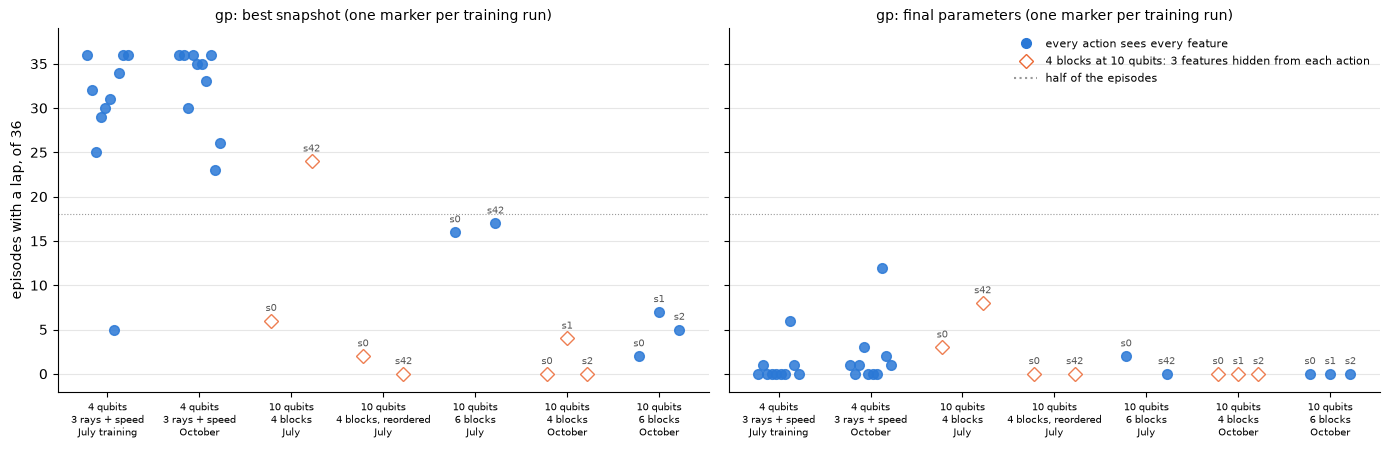

In [15]:
if runs:
    groups = []  # (label, colour, marker, filled, [(seed, best, final)])
    for study, variant, label in (("gp_4q", "base", "4 qubits\n3 rays + speed\nJuly training"),
                                  ("gp_4q", "eps30_trunc", "4 qubits\n3 rays + speed\nOctober")):
        entry = lane(study, variant)
        if entry is not None:
            groups.append((label, C_FULL, "o", True,
                           [(row["seed"], row["best_lapped"], row["final_lapped"])
                            for row in entry["per_seed"]]))
    keys = dict.fromkeys((r["recipe"], r["layers"], r["layout"]) for r in runs)
    for recipe, layers, layout in keys:
        members = [r for r in runs
                   if (r["recipe"], r["layers"], r["layout"]) == (recipe, layers, layout)]
        blind = blind_pairs(10, layers) > 0
        label = f"10 qubits\n{layers} blocks" + (", reordered" if "reordered" in layout else "")
        label += f"\n{recipe}"
        groups.append((label, C_BLIND if blind else C_FULL, "D" if blind else "o", not blind,
                       [(r["seed"], r["best"], r["final"]) for r in members]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
    for ax, column, title in ((axes[0], 1, "best snapshot"), (axes[1], 2, "final parameters")):
        for x, (_, color, marker, filled, members) in enumerate(groups):
            offsets = np.linspace(-0.22, 0.22, len(members)) if len(members) > 1 else [0.0]
            for dx, member in zip(offsets, members, strict=True):
                ax.plot(x + dx, member[column], marker, color=color, ms=7,
                        mfc=color if filled else "white", alpha=0.85)
                if len(members) <= 3:
                    ax.annotate(f"s{member[0]}", (x + dx, member[column]), fontsize=7,
                                textcoords="offset points", xytext=(0, 7), ha="center",
                                color="0.35")
        ax.axhline(18, color="0.6", lw=0.8, ls=":")
        ax.set_xticks(range(len(groups)), [g[0] for g in groups], fontsize=7.5)
        ax.set_title(f"gp: {title} (one marker per training run)", fontsize=10)
        ax.set_ylim(-2, 39)
        ax.grid(axis="y", color="0.9", lw=0.8)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel("episodes with a lap, of 36")
    handles = [plt.Line2D([], [], color=C_FULL, marker="o", ls="", ms=7,
                          label="every action sees every feature"),
               plt.Line2D([], [], color=C_BLIND, marker="D", ls="", ms=7, mfc="white",
                          label="4 blocks at 10 qubits: 3 features hidden from each action"),
               plt.Line2D([], [], color="0.6", ls=":", label="half of the episodes")]
    axes[1].legend(handles=handles, fontsize=8, frameon=False, loc="upper right")
    fig.tight_layout()
    plt.show()

**What can be concluded.**

- *The recipe that works at 4 qubits does not carry over.* None of the six
  October-recipe runs at 10 qubits has a best snapshot that laps in half of
  its check episodes, against every one of the ten 4-qubit seeds under the
  same recipe. Six runs are few, but none-of-six against ten-of-ten is not a
  subtle difference — and it holds at both depths, so blind actions alone
  do not explain it.
- *Under the July recipe the 10-qubit feature circuit can learn gp* — one of
  the six runs laps in two thirds of its check episodes — *and how well is
  dominated by the seed.* The same 4-block configuration laps in 24 of 36
  episodes with one seed and in 6 with the other.
- *The final parameters lap rarely or never in all twelve runs.* Whatever a
  10-qubit run learned on gp, it did not keep.
- *More rays alone did not help on gp either.* The one multi-seed lane above
  4 qubits with plain rays — the 6-qubit profile under the July training
  recipe, in the reference table — has no reliable seed, against nine of ten
  at 4 qubits. On the hard track the evidence that exists says a wider
  circuit is *harder* to train, not easier.

**What cannot be concluded.**

- *Whether 6 blocks beat 4 at 10 qubits on gp.* Two or three seeds per arm,
  and under the July recipe the best single run is a 4-block one. The 6-block
  runs are the more even pair; that is an observation about two runs.
- *Whether the feature order matters.* The hand-reordered layout lapped worst
  on both seeds, which is a hint that it does — from two seeds and one
  permutation that was never compared with any other.
- *Why the October recipe fails here.* The 10-qubit runs differ from the
  4-qubit ones in register size, observation (features instead of rays) and
  parameter count at once, and no run varies them one at a time.
- *Which recipe is better at 10 qubits.* The two sets use different seeds and
  different snapshot-selection protocols; only the direction is clear.
- *How a 10-qubit circuit compares with the 4-qubit one or with the MLP on
  gp.* No 10-qubit lane has enough seeds to put an interval on anything.

The practical consequence: `quantum_gp_q10` remains the July file — 4 blocks,
with the blind spots listed in Part D — and a dependable 10-qubit gp driver is
an open problem, not a result.

## D — Better features instead of more rays?

More rays are one way to spend qubits. The observation registry
(`[observation] features` in the config, `traqmania/env/racing_env.py`) offers
another: any qubit can carry an engineered, track-aware scalar instead, each
normalized to $[0, 1]$:

- **`curvature_ahead`** — the tightest centerline curvature within the next
  `lookahead_m` metres, relative to the track's maximum: *how sharp is the
  next corner?* (A suffix such as `"curvature_ahead:30"` sets its own
  horizon.)
- **`lateral_offset`** — signed offset from the centerline in half-widths
  (0.5 = on the centerline): *where am I between the walls?*
- **`heading_error`** — wrapped angle to the track tangent (0.5 = aligned):
  *am I pointing the right way?*
- **`corner_speed_ratio`** — current speed over the fastest speed the car can
  hold through the corner ahead (0.5 = exactly at the limit): *will I make
  it?*

The last one comes from the car model. The car turns at
$\dot\theta = \text{steer}\cdot k_\text{steer}\cdot f(v)$ with
$f(v) = 2\,v\,v_\text{turn} / (v_\text{turn}^2 + v^2)$, and holding a circle
of radius $R$ needs $\dot\theta = v/R$, so full lock holds the corner only
while

$$v \;\le\; v_\text{safe}(R) = \sqrt{2\,k_\text{steer}\,v_\text{turn}\,R - v_\text{turn}^2}.$$

In [16]:
print("feature kinds in the registry:", ", ".join(FEATURE_KINDS))
phys = load_config()["physics"]
k_steer, v_turn = phys["k_steer"], phys["v_turn"]
print(f"\nk_steer = {k_steer}, v_turn = {v_turn}, v_max = {phys['v_max']}")
print(f"tightest holdable corner: R = v_turn / (2 k_steer) = {v_turn / (2 * k_steer):.2f} units")
for radius in (2, 5, 10, 20, 40):
    v_safe = np.sqrt(max(0.0, 2 * k_steer * v_turn * radius - v_turn**2))
    print(f"  R = {radius:>2} units -> v_safe = {v_safe:5.1f}"
          + ("  (> v_max: flat out is fine)" if v_safe > phys["v_max"] else ""))

feature kinds in the registry: rays, speed, curvature_ahead, lateral_offset, heading_error, corner_speed_ratio

k_steer = 2.6, v_turn = 9.0, v_max = 25.0
tightest holdable corner: R = v_turn / (2 k_steer) = 1.73 units
  R =  2 units -> v_safe =   3.5
  R =  5 units -> v_safe =  12.4
  R = 10 units -> v_safe =  19.7
  R = 20 units -> v_safe =  29.2  (> v_max: flat out is fine)
  R = 40 units -> v_safe =  42.3  (> v_max: flat out is fine)


### What the features report along a lap

A small live demonstration. The bundled 4-qubit gp driver drives one lap
seeing only its three rays and its speed; alongside, the cell computes what
each engineered feature *would have* reported at every decision of that lap.

quantum_gp (4 qubits, sees ray -60°, ray 0°, ray +60°, speed): lap in 28.4 s, 284 decisions, 51 of them Brake
corner speed peaks at 0.496 on this lap (0.5 = exactly at the limit)
Brake decisions: 12 of 83 with no corner within the lookahead, 39 of 201 with one


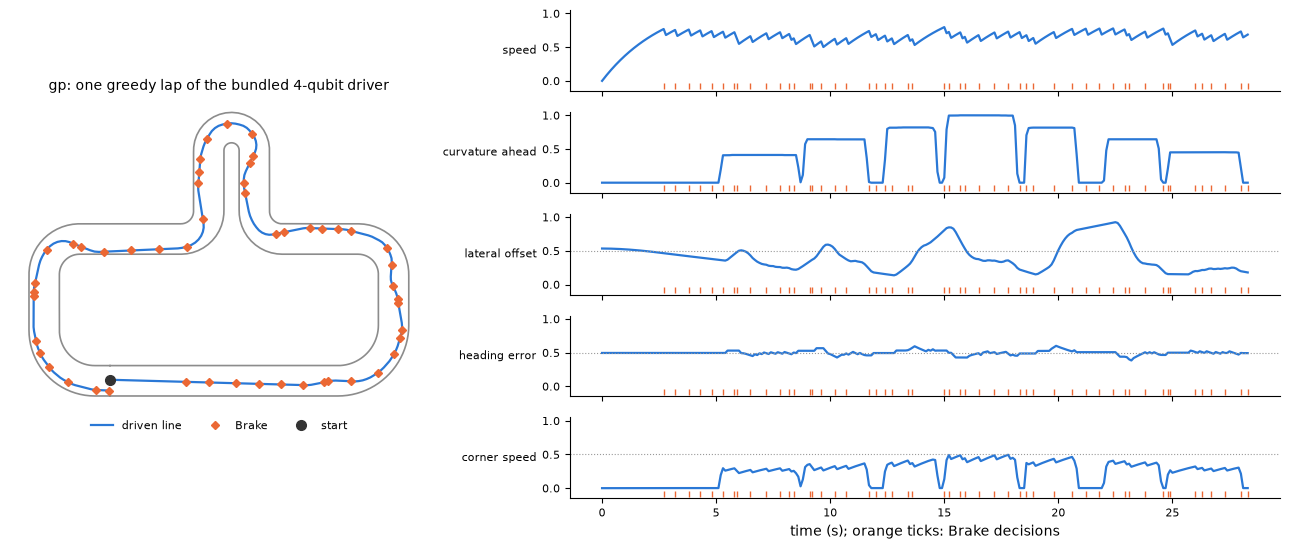

In [17]:
drivers = {d.id: d for d in records.discover_drivers()}
gp_driver = drivers["quantum_gp"]
gp_track = Track.load("gp", gp_driver.config["track"]["resample_spacing"])
qfunc = QuantumQFunction(gp_driver.config["circuit"])
qfunc.set_params(np.load(gp_driver.path)["params"])

env = RacingEnv(gp_track, gp_driver.config, n_envs=1, seed=0)
obs, states, actions, lap_time = env.reset(), [], [], None
for _ in range(env.max_decisions):
    states.append(env.state[0].copy())
    action = qfunc.q_values(obs).argmax(axis=1)
    actions.append(int(action[0]))
    obs, _, done, info = env.step(action)
    if info["lap"][0] >= 1:
        lap_time = float(info["last_lap_time"][0])
    if lap_time is not None or done[0]:
        break
states, actions = np.array(states), np.array(actions)
braking = actions == ACTIONS.index("Brake")
print("quantum_gp (4 qubits, sees " + ", ".join(env.feature_names) + "): "
      + (f"lap in {lap_time:.1f} s" if lap_time else "no lap in this episode")
      + f", {len(actions)} decisions, {int(braking.sum())} of them Brake")

# the same states through an observer that has the engineered features
feature_cfg = copy.deepcopy(load_config("q10"))
feature_cfg["observation"].update(GP_FEATURES or {
    "ray_angles_deg": [-60.0, -30.0, 0.0, 30.0, 60.0],
    "features": ["rays", "speed", "curvature_ahead", "lateral_offset", "heading_error",
                 "corner_speed_ratio"]})
observer = CarObserver(gp_track, feature_cfg)
seen = observer.observe(states)
shown = [name for name in observer.feature_names if not name.startswith("ray")]
t = np.arange(len(states)) * env.decision_dt
corner = seen[:, observer.feature_names.index("corner speed")]
clear = seen[:, observer.feature_names.index("curvature ahead")] < 0.05
print(f"corner speed peaks at {corner.max():.3f} on this lap (0.5 = exactly at the limit)")
print(f"Brake decisions: {int((braking & clear).sum())} of {int(clear.sum())} with no corner "
      f"within the lookahead, {int((braking & ~clear).sum())} of {int((~clear).sum())} with one")

fig = plt.figure(figsize=(13, 5.6))
grid = fig.add_gridspec(len(shown), 2, width_ratios=(1, 1.7))
ax_map = fig.add_subplot(grid[:, 0])
for side in (1.0, -1.0):  # the two track boundaries
    edge = gp_track.centerline + side * gp_track.half_width * gp_track.normals
    ax_map.plot(*np.vstack([edge, edge[:1]]).T, color="0.55", lw=1.2)
ax_map.plot(states[:, 0], states[:, 1], color=C_FULL, lw=1.6, label="driven line")
ax_map.plot(states[braking, 0], states[braking, 1], "D", color=C_BLIND, ms=4, label="Brake")
ax_map.plot(*states[0, :2], "o", color="0.2", ms=7, label="start")
ax_map.set_aspect("equal")
ax_map.axis("off")
ax_map.legend(fontsize=8, frameon=False, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.0))
ax_map.set_title("gp: one greedy lap of the bundled 4-qubit driver", fontsize=10)
for k, name in enumerate(shown):
    ax = fig.add_subplot(grid[k, 1])
    ax.plot(t, seen[:, observer.feature_names.index(name)], color=C_FULL, lw=1.6)
    ax.plot(t[braking], np.full(braking.sum(), -0.08), "|", color=C_BLIND, ms=5)
    if name in ("lateral offset", "heading error", "corner speed"):
        ax.axhline(0.5, color="0.6", lw=0.8, ls=":")
    ax.set_ylim(-0.15, 1.05)
    ax.set_ylabel(name, fontsize=8, rotation=0, ha="right", va="center")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, labelbottom=k == len(shown) - 1)
ax.set_xlabel("time (s); orange ticks: Brake decisions")
fig.tight_layout()
plt.show()

The dotted lines mark the neutral value 0.5: on the centerline, aligned with
the track, exactly at the corner's speed limit. `curvature ahead` steps up
*before* each corner arrives — it is a look-ahead — and `corner speed` above
its line would say "too fast for what is coming". In the lap stored with this
notebook it peaks just under that line: this driver holds its speed down with
brake taps all around the lap — also where no corner is within the
lookahead; the cell prints the counts — and so arrives at every corner at or
below its limit. How much margin is left is exactly what `corner speed` puts
into one number, and what three rays and a speedometer contain only
implicitly. That is the case for engineered features. Whether a small circuit
can *use* them is an empirical question, and one condition is structural: the
action has to be able to see the feature at all.

### Which action sees which feature?

Feature $j$ sits on qubit $j$ and the actions read qubits 0–3, so at a depth
without full visibility the feature *order* decides which action is blind to
what. For the engineered alternatives of the wide profiles (the commented-out
observations in `q6.toml`, `q8.toml`, `q10.toml`) — at 4 blocks, the depth of
every July run, and at the depth each profile ships with today — and for the
bundled 10-qubit gp driver:

In [18]:
ALTERNATIVES = {  # the engineered-feature observation each wide profile offers
    6: {"ray_angles_deg": [-60.0, 0.0, 60.0],
        "features": ["rays", "speed", "curvature_ahead", "corner_speed_ratio"]},
    8: {"ray_angles_deg": [-60.0, 0.0, 60.0],
        "features": ["rays", "speed", "curvature_ahead", "lateral_offset", "heading_error",
                     "corner_speed_ratio"]},
    10: GP_FEATURES or {"ray_angles_deg": [-60.0, -30.0, 0.0, 30.0, 60.0],
                        "features": ["rays", "speed", "curvature_ahead", "lateral_offset",
                                     "heading_error", "corner_speed_ratio"]},
}


def print_view(label, names, layers):
    hidden = lightcone.blind_spots(names, layers)
    print(f"  {label}: " + ("every action sees every feature" if not hidden else "hidden -"))
    for line in hidden:
        print(f"      {line}")


for n, alternative in ALTERNATIVES.items():
    layers, _, cfg = SHIPPED[n]
    cfg = copy.deepcopy(cfg)
    cfg["observation"].update(alternative)
    print(f"{n} qubits, {observation_text(cfg)} "
          f"(full view needs {lightcone.min_layers_full_visibility(n)} blocks)")
    for depth in sorted({4, layers}):
        label = f"{depth} blocks" + (", every July run" if depth == 4 else "")
        label += ", what the profile ships today" if depth == layers else ""
        print_view(label, CarObserver(oval, cfg).feature_names, depth)
if "quantum_gp_q10" in drivers:
    d = drivers["quantum_gp_q10"]
    layers = int(d.config["circuit"]["n_layers"])
    print("bundled quantum_gp_q10, " + observation_text(d.config))
    print_view(f"{layers} blocks", CarObserver(gp_track, d.config).feature_names, layers)

6 qubits, 3 rays + speed + curvature ahead + corner speed (full view needs 4 blocks)
  4 blocks, every July run, what the profile ships today: every action sees every feature
8 qubits, 3 rays + speed + curvature ahead + lateral offset + heading error + corner speed (full view needs 5 blocks)
  4 blocks, every July run: hidden -
      Right (Z_0) cannot see: curvature ahead
      Straight (Z_1) cannot see: lateral offset
      Left (Z_2) cannot see: heading error
      Brake (Z_3) cannot see: corner speed
  5 blocks, what the profile ships today: every action sees every feature
10 qubits, 5 rays + speed + curvature ahead + lateral offset + heading error + corner speed (full view needs 6 blocks)
  4 blocks, every July run, what the profile ships today: hidden -
      Right (Z_0) cannot see: ray +60°, speed, curvature ahead
      Straight (Z_1) cannot see: speed, curvature ahead, lateral offset
      Left (Z_2) cannot see: curvature ahead, lateral offset, heading error
      Brake (Z_3) c

### What the July feature experiments did and did not show

In July 2026 this notebook compared rays-only and engineered-feature
observations at 6, 8 and 10 qubits on the oval, with an MLP control, and
reported two readings in turn: first that features helped the circuit and not
the MLP, then — after a change of the physics constants and with three seeds
per variant — that this asymmetry had dissolved. **Neither reading is
reported here as a finding, and no number from those runs is repeated**,
for three reasons:

- *The protocol.* One to three seeds per variant; snapshots chosen on 4
  distinct evaluation episodes; and the quantity compared was the lap time of
  a best snapshot — the statistic most inflated by selection. Part B shows how
  far best snapshots and final parameters can be apart.
- *The circuit.* Every run used 4 blocks. At 8 and 10 qubits each action was
  therefore blind to one and to three of its inputs; the cell above shows what
  that means for the feature layouts — for instance which action cannot see
  `corner speed`. A rays-versus-features comparison in which the feature
  built for braking is hidden from the brake does not test the feature.
- *No re-measurement.* The October studies contain no rays-versus-features
  lanes. The only post-audit runs with features are the twelve gp runs of
  Part C, and they have no rays-only counterpart at 10 qubits.

What those experiments *did* establish is modest and structural: the
observation registry works end to end (a driver's sidecar records the
observation it was trained with and the server adopts it), and a circuit can
be trained on feature observations — on the oval, and in single runs on gp.
What they did *not* establish: that features help the circuit, that they hurt
it, that it makes no difference, or that circuit and MLP respond differently.
The same status applies to the July follow-up mechanisms built on top —
wider action sets read from extra qubits, the multi-horizon "braking ladder",
the pace fine-tune: single-seed runs on partially blind circuits, not
re-measured. They are exploratory results under the old protocol.

**What a real test needs** is cheap to state: the same qubit count and a
depth with full visibility in both arms, rays against features (and a second
feature order as a control), an MLP on both observations, and enough seeds
for an interval — for example, at 6 qubits:

```
python tools/study.py run --out studies/features_q6 --track oval --profile q6 \
    --episodes 800 --seeds 0-7 --set training.bootstrap_truncation=true \
    --variant rays --variant 'mlp_rays:agent=mlp' \
    --variant 'features:observation.ray_angles_deg=[-60.0,0.0,60.0],observation.features=["rays","speed","curvature_ahead","corner_speed_ratio"]' \
    --variant 'mlp_features:agent=mlp,observation.ray_angles_deg=[-60.0,0.0,60.0],observation.features=["rays","speed","curvature_ahead","corner_speed_ratio"]'
```

Until something like it has run, "better features" is a hypothesis this
project can state and cannot yet answer.

## What this shows — and what it doesn't

Being honest matters more than being exciting.

- **More qubits bought no consistent gain.** On oval and chicane, with one
  recipe and 6–8 seeds per lane: six qubits have the best point estimates for
  stability and final parameters on both tracks, eight qubits fall back to
  the 4-qubit level on both at either depth, and lap time follows no order.
  Among the 4-, 6- and 8-qubit lanes few differences between circuit sizes
  are statistically supported — one favours 6 qubits over 4, three count
  against 8 qubits.
- **Depth should follow width — on a structural argument and thin data.**
  That 4 blocks hide inputs from actions at 8 and 10 qubits is arithmetic
  (Part A). What it costs was measured once, at 8 qubits with six seeds per
  arm: one supported difference (final parameters on the oval), most of the
  rest in the same direction without support. The `q8` profile now ships 5
  blocks. Whether 10 qubits show the same is what the pending study measures.
- **The MLP baseline is ahead.** Under the common recipe: earlier first lap,
  far more stable, final parameters that still lap, faster on the oval — at
  every observation width, at about a hundredth of the circuit's compute per
  decision or less. The robust recipe brings the 6-qubit circuit level with
  its MLP in stability on the oval, and in nothing else. Nothing here suggests
  quantum usefulness, and none should be inferred;
  [notebook 07](07_light_cones_and_classical_surrogates.ipynb) explains why
  none was possible at this scale in the first place.
- **The hard track above 4 qubits is unsolved.** The recipe that stabilises
  the 4-qubit circuit on gp fails at 10 qubits, a few July-recipe runs lap but
  do not hold, and nothing about depth or feature order can be concluded from
  two or three seeds.
- **Features are untested.** The registry exists and works; whether a smarter
  observation beats a wider one has not been measured under a protocol that
  could tell.
- **Mind the scope.** Two easy tracks, one hard one, one environment, recipes
  developed at 4 qubits, 6–10 seeds, an exact simulator. "Supported" means
  supported within that protocol. And the bundled drivers are picks from
  these studies, so their lap counts are selections, not expectations.

**Next:** [07 — Light cones and classical surrogates](07_light_cones_and_classical_surrogates.ipynb)
takes the circuit apart: why a readout can only see part of the register, and
why a classical model can stand in for the trained circuit.

In [19]:
if PENDING:
    print("PENDING when this notebook was executed (re-execute once the summaries exist):")
    for study, variant in PENDING:
        print(f"  data/studies/{study}: variant '{variant}'")
else:
    print("no study was pending: every lane this notebook asks for was found")
print(f"\nnotebook executed in {time.perf_counter() - T_START:.0f} s")

PENDING when this notebook was executed (re-execute once the summaries exist):
  data/studies/oval_q10: variant 'L4'
  data/studies/oval_q10: variant 'L6'
  data/studies/oval_q10: variant 'mlp'
  data/studies/chicane_q10: variant 'L4'
  data/studies/chicane_q10: variant 'L6'
  data/studies/chicane_q10: variant 'mlp'

notebook executed in 15 s
